# 00 Major Index Data Collection And EDA

This notebook prepares the research dataset for the major-index forecasting study.

## Sample
- Indices: `^IXIC`, `^GSPC`, `^DJI`, `^RUA`
- Calendar span: `2022-01-01` to `2026-03-31`
- Hyperparameter tuning: windows whose test-point date falls in `2022`
- Evaluation: windows whose test-point date falls in `2023-01-01` to `2026-03-31`

## Deliverables
- Clean daily OHLCV data
- Descriptive statistics and comparison tables
- A technical-feature panel for all downstream models
- Visual checks for trend, return behavior, and cross-index co-movement

## Feature Set Confirmed
- `close`
- `rsi14`
- `macd_hist`
- `bb_z20`
- `roc10`
- `vol20`
- `sma10_gap`
- `atr14_pct`
- `williams_r14`


In [1]:
from __future__ import annotations

import os
import time
from contextlib import contextmanager
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from IPython.display import display


def resolve_project_root() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Run this notebook from the project root or its notebooks directory.")


PROJECT_ROOT = resolve_project_root()
OUTPUT_ROOT = PROJECT_ROOT / 'outputs' / '00_major_index_data_collection_and_eda'
RAW_OUTPUT_DIR = OUTPUT_ROOT / 'raw'
TABLE_DIR = OUTPUT_ROOT / 'tables'
FIG_DIR = OUTPUT_ROOT / 'figures'
CACHE_DIR = PROJECT_ROOT / 'data_cache' / 'major_index_eda'
for directory in [OUTPUT_ROOT, RAW_OUTPUT_DIR, TABLE_DIR, FIG_DIR, CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

REQUESTED_START_DATE = '2022-01-01'
REQUESTED_END_DATE = '2026-03-31'
HP_TUNING_START_DATE = '2022-01-01'
HP_TUNING_END_DATE = '2022-12-31'
EVALUATION_START_DATE = '2023-01-01'
TRADING_DAYS_PER_YEAR = 252

INDEX_META = {
    'NASDAQ': {'symbol': '^IXIC', 'label': 'Nasdaq Composite'},
    'SP500': {'symbol': '^GSPC', 'label': 'S&P 500'},
    'DOWJONES': {'symbol': '^DJI', 'label': 'Dow Jones Industrial Average'},
    'RUSSELL3000': {'symbol': '^RUA', 'label': 'Russell 3000'},
}

MODELING_FEATURE_COLS = ['rsi14', 'macd_hist', 'bb_z20', 'roc10', 'vol20', 'sma10_gap', 'atr14_pct', 'williams_r14']

TECHNICAL_INDICATOR_CATALOG = pd.DataFrame(
    [
        {'feature_name': 'rsi14', 'type': 'technical_indicator', 'description': '14-day relative strength index.'},
        {'feature_name': 'macd_hist', 'type': 'technical_indicator', 'description': 'MACD histogram from 12/26 EMA with 9-day signal.'},
        {'feature_name': 'bb_z20', 'type': 'technical_indicator', 'description': '20-day Bollinger standardized deviation from rolling mean.'},
        {'feature_name': 'roc10', 'type': 'technical_indicator', 'description': '10-day rate of change.'},
        {'feature_name': 'vol20', 'type': 'technical_indicator', 'description': '20-day rolling realized volatility of daily returns.'},
        {'feature_name': 'sma10_gap', 'type': 'technical_indicator', 'description': 'Percent gap between the close and its 10-day simple moving average.'},
        {'feature_name': 'atr14_pct', 'type': 'technical_indicator', 'description': '14-day average true range scaled by the close level.'},
        {'feature_name': 'williams_r14', 'type': 'technical_indicator', 'description': '14-day Williams %R oscillator derived from high, low, and close.'},
    ]
)

MASTER_BUNDLE_PATH = OUTPUT_ROOT / 'major_index_data_eda_bundle.joblib'
RAW_PANEL_PATH = RAW_OUTPUT_DIR / 'major_index_raw_panel.csv'
RETURN_PANEL_PATH = RAW_OUTPUT_DIR / 'major_index_return_panel.csv'
FEATURE_PANEL_PATH = RAW_OUTPUT_DIR / 'major_index_feature_panel.csv'

os.environ.setdefault('MPLCONFIGDIR', str((OUTPUT_ROOT / '.mplconfig').resolve()))
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

TIMING_ROWS: list[dict] = []


In [2]:
@contextmanager
def timed_step(step_name: str):
    start = time.perf_counter()
    yield
    elapsed_seconds = time.perf_counter() - start
    TIMING_ROWS.append({'step': step_name, 'elapsed_seconds': elapsed_seconds})
    print(f'[TIMER] {step_name}: {elapsed_seconds:.2f}s')


def cache_path(index_key: str, start_date: str, end_date: str) -> Path:
    return CACHE_DIR / f"{index_key.lower()}_{start_date}_{end_date}.csv"


def is_valid_ohlcv_frame(frame: pd.DataFrame) -> bool:
    required = {'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'}
    return frame is not None and not frame.empty and required.issubset(frame.columns) and isinstance(frame.index, pd.DatetimeIndex)


def read_cached_ohlcv(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        return None
    try:
        frame = pd.read_csv(path, index_col=0, parse_dates=True)
        frame.index.name = None
        if is_valid_ohlcv_frame(frame):
            return frame.sort_index()
    except Exception:
        return None
    return None


def download_ohlcv(index_key: str, symbol: str, start_date: str, end_date: str) -> pd.DataFrame:
    path = cache_path(index_key, start_date, end_date)
    cached = read_cached_ohlcv(path)
    if cached is not None:
        return cached

    yfinance_end = (pd.Timestamp(end_date) + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
    frame = yf.download(symbol, start=start_date, end=yfinance_end, progress=False, auto_adjust=False)
    if isinstance(frame.columns, pd.MultiIndex):
        frame.columns = [col[0] for col in frame.columns]
    if not is_valid_ohlcv_frame(frame):
        raise ValueError(f'Invalid OHLCV data for {index_key} ({symbol}).')
    frame = frame[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].dropna().sort_index()
    frame.to_csv(path)
    return frame


def compute_rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gains = delta.clip(lower=0.0)
    losses = -delta.clip(upper=0.0)
    avg_gain = gains.ewm(alpha=1 / period, adjust=False).mean()
    avg_loss = losses.ewm(alpha=1 / period, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0.0, np.nan)
    return 100.0 - (100.0 / (1.0 + rs))


def compute_feature_frame(index_key: str, raw_frame: pd.DataFrame) -> pd.DataFrame:
    close = raw_frame['Close'].astype(float)
    high = raw_frame['High'].astype(float)
    low = raw_frame['Low'].astype(float)
    feature_frame = pd.DataFrame(index=raw_frame.index)
    feature_frame['index_key'] = index_key
    feature_frame['close'] = close
    feature_frame['daily_return'] = close.pct_change()
    feature_frame['rsi14'] = compute_rsi(close, 14)
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    macd_signal = macd.ewm(span=9, adjust=False).mean()
    feature_frame['macd_hist'] = macd - macd_signal
    ma20 = close.rolling(20).mean()
    sd20 = close.rolling(20).std()
    feature_frame['bb_z20'] = (close - ma20) / sd20.replace(0.0, np.nan)
    feature_frame['roc10'] = close.pct_change(10)
    feature_frame['vol20'] = close.pct_change().rolling(20).std()
    sma10 = close.rolling(10).mean()
    feature_frame['sma10_gap'] = (close / sma10) - 1.0
    prev_close = close.shift(1)
    true_range = pd.concat([(high - low), (high - prev_close).abs(), (low - prev_close).abs()], axis=1).max(axis=1)
    atr14 = true_range.rolling(14).mean()
    feature_frame['atr14_pct'] = atr14 / close.replace(0.0, np.nan)
    highest_high14 = high.rolling(14).max()
    lowest_low14 = low.rolling(14).min()
    denominator = (highest_high14 - lowest_low14).replace(0.0, np.nan)
    feature_frame['williams_r14'] = -100.0 * ((highest_high14 - close) / denominator)
    return feature_frame.reset_index(names='Date')


def max_drawdown_from_close(close: pd.Series) -> float:
    wealth = close.astype(float) / float(close.iloc[0])
    running_peak = wealth.cummax()
    drawdown = (wealth / running_peak) - 1.0
    return float(drawdown.min())


def trading_split_preview(trading_dates: pd.Series) -> pd.DataFrame:
    ordered = pd.to_datetime(pd.Series(trading_dates).dropna().drop_duplicates()).sort_values().reset_index(drop=True)
    tuning_mask = ordered <= pd.Timestamp(HP_TUNING_END_DATE)
    tuning_dates = ordered.loc[tuning_mask]
    evaluation_dates = ordered.loc[~tuning_mask]
    return pd.DataFrame(
        [
            {
                'requested_start_date': REQUESTED_START_DATE,
                'requested_end_date': REQUESTED_END_DATE,
                'actual_first_trading_date': ordered.iloc[0],
                'actual_last_trading_date': ordered.iloc[-1],
                'hp_tuning_start_date': pd.Timestamp(HP_TUNING_START_DATE),
                'hp_tuning_end_date': pd.Timestamp(HP_TUNING_END_DATE),
                'evaluation_start_date': pd.Timestamp(EVALUATION_START_DATE),
                'tuning_last_trading_date': tuning_dates.iloc[-1] if len(tuning_dates) else pd.NaT,
                'evaluation_first_trading_date': evaluation_dates.iloc[0] if len(evaluation_dates) else pd.NaT,
                'tuning_rows': int(len(tuning_dates)),
                'evaluation_rows': int(len(evaluation_dates)),
            }
        ]
    )


In [3]:
with timed_step('download_raw_data'):
    raw_frames: dict[str, pd.DataFrame] = {}
    for index_key, meta in INDEX_META.items():
        frame = download_ohlcv(
            index_key=index_key,
            symbol=meta['symbol'],
            start_date=REQUESTED_START_DATE,
            end_date=REQUESTED_END_DATE,
        )
        frame = frame.copy()
        frame['index_key'] = index_key
        frame['index_label'] = meta['label']
        raw_frames[index_key] = frame
        print(
            f"{index_key}: rows={len(frame):,} | first={frame.index.min().date()} | last={frame.index.max().date()}"
        )

raw_panel = (
    pd.concat(raw_frames, names=['index_key', 'Date'])
    .reset_index(level=0, drop=True)
    .reset_index(names='Date')
    .sort_values(['Date', 'index_key'])
    .reset_index(drop=True)
)
raw_panel.to_csv(RAW_PANEL_PATH, index=False)
print('Raw panel prepared')
display(raw_panel.head())


NASDAQ: rows=1,064 | first=2022-01-03 | last=2026-03-31
SP500: rows=1,064 | first=2022-01-03 | last=2026-03-31
DOWJONES: rows=1,064 | first=2022-01-03 | last=2026-03-31
RUSSELL3000: rows=1,064 | first=2022-01-03 | last=2026-03-31
[TIMER] download_raw_data: 1.11s
Raw panel prepared


,Date,Open,High,Low,Close,Adj Close,Volume,index_key,index_label
0,2022-01-03,36321.589844,36595.820312,36246.449219,36585.058594,36585.058594,347930000,DOWJONES,Dow Jones Industrial Average
1,2022-01-03,15732.500000,15832.799805,15644.089844,15832.799805,15832.799805,4429960000,NASDAQ,Nasdaq Composite
2,2022-01-03,2788.020020,2804.939941,2783.040039,2804.929932,2804.929932,0,RUSSELL3000,Russell 3000
3,2022-01-03,4778.140137,4796.640137,4758.169922,4796.560059,4796.560059,3831020000,SP500,S&P 500
4,2022-01-04,36636.000000,36934.839844,36636.000000,36799.648438,36799.648438,435080000,DOWJONES,Dow Jones Industrial Average


In [4]:
with timed_step('data_quality_and_split_preview'):
    quality_rows = []
    for index_key, frame in raw_frames.items():
        quality_rows.append(
            {
                'index_key': index_key,
                'index_label': INDEX_META[index_key]['label'],
                'rows': int(len(frame)),
                'first_date': pd.Timestamp(frame.index.min()),
                'last_date': pd.Timestamp(frame.index.max()),
                'duplicate_dates': int(frame.index.duplicated().sum()),
                'missing_open': int(frame['Open'].isna().sum()),
                'missing_high': int(frame['High'].isna().sum()),
                'missing_low': int(frame['Low'].isna().sum()),
                'missing_close': int(frame['Close'].isna().sum()),
                'missing_adj_close': int(frame['Adj Close'].isna().sum()),
                'missing_volume': int(frame['Volume'].isna().sum()),
            }
        )
    quality_table = pd.DataFrame(quality_rows).sort_values('index_key').reset_index(drop=True)
    split_preview = trading_split_preview(raw_panel['Date'])

quality_table.to_csv(TABLE_DIR / 'data_quality_summary.csv', index=False)
split_preview.to_csv(TABLE_DIR / 'split_preview.csv', index=False)

print('Data quality summary')
display(quality_table)
print('Workflow split preview')
display(split_preview)


[TIMER] data_quality_and_split_preview: 0.00s
Data quality summary


,index_key,index_label,rows,first_date,last_date,duplicate_dates,missing_open,missing_high,missing_low,missing_close,missing_adj_close,missing_volume
0,DOWJONES,Dow Jones Industrial Average,1064,2022-01-03,2026-03-31,0,0,0,0,0,0,0
1,NASDAQ,Nasdaq Composite,1064,2022-01-03,2026-03-31,0,0,0,0,0,0,0
2,RUSSELL3000,Russell 3000,1064,2022-01-03,2026-03-31,0,0,0,0,0,0,0
3,SP500,S&P 500,1064,2022-01-03,2026-03-31,0,0,0,0,0,0,0


Workflow split preview


,requested_start_date,requested_end_date,actual_first_trading_date,actual_last_trading_date,hp_tuning_start_date,hp_tuning_end_date,evaluation_start_date,tuning_last_trading_date,evaluation_first_trading_date,tuning_rows,evaluation_rows
0,2022-01-01,2026-03-31,2022-01-03,2026-03-31,2022-01-01,2022-12-31,2023-01-01,2022-12-30,2023-01-03,251,813


In [5]:
with timed_step('descriptive_statistics'):
    return_frames = []
    close_stats_rows = []
    return_stats_rows = []

    for index_key, frame in raw_frames.items():
        close = frame['Close'].astype(float)
        returns = close.pct_change().dropna()
        return_frames.append(
            pd.DataFrame(
                {
                    'Date': returns.index,
                    'index_key': index_key,
                    'daily_return': returns.to_numpy(dtype=float),
                }
            )
        )
        close_stats_rows.append(
            {
                'index_key': index_key,
                'index_label': INDEX_META[index_key]['label'],
                'close_mean': float(close.mean()),
                'close_median': float(close.median()),
                'close_std': float(close.std()),
                'close_min': float(close.min()),
                'close_max': float(close.max()),
                'start_close': float(close.iloc[0]),
                'end_close': float(close.iloc[-1]),
                'sample_return_pct': float((close.iloc[-1] / close.iloc[0] - 1.0) * 100.0),
                'max_drawdown_pct': float(max_drawdown_from_close(close) * 100.0),
            }
        )
        return_stats_rows.append(
            {
                'index_key': index_key,
                'index_label': INDEX_META[index_key]['label'],
                'daily_mean_pct': float(returns.mean() * 100.0),
                'daily_std_pct': float(returns.std() * 100.0),
                'annualized_vol_pct': float(returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR) * 100.0),
                'daily_skew': float(returns.skew()),
                'daily_kurtosis': float(returns.kurtosis()),
                'daily_min_pct': float(returns.min() * 100.0),
                'daily_max_pct': float(returns.max() * 100.0),
                'positive_day_share_pct': float((returns.gt(0).mean()) * 100.0),
            }
        )

    return_panel = pd.concat(return_frames, ignore_index=True).sort_values(['Date', 'index_key']).reset_index(drop=True)
    close_stats = pd.DataFrame(close_stats_rows).sort_values('index_key').reset_index(drop=True)
    return_stats = pd.DataFrame(return_stats_rows).sort_values('index_key').reset_index(drop=True)

return_panel.to_csv(RETURN_PANEL_PATH, index=False)
close_stats.to_csv(TABLE_DIR / 'close_level_summary.csv', index=False)
return_stats.to_csv(TABLE_DIR / 'return_summary.csv', index=False)

print('Close-level summary')
display(close_stats)
print('Return summary')
display(return_stats)


[TIMER] descriptive_statistics: 0.00s
Close-level summary


,index_key,index_label,close_mean,close_median,close_std,close_min,close_max,start_close,end_close,sample_return_pct,max_drawdown_pct
0,DOWJONES,Dow Jones Industrial Average,38513.943894,38160.355469,5457.838493,28725.509766,50188.140625,36585.058594,46341.511719,26.667863,-21.940804
1,NASDAQ,Nasdaq Composite,16143.535506,15625.379883,3944.364507,10213.290039,23958.470703,15832.799805,21590.630859,36.366474,-35.492837
2,RUSSELL3000,Russell 3000,2926.668485,2858.559937,553.996513,2076.070068,3971.580078,2804.929932,3717.560059,32.536646,-25.984958
3,SP500,S&P 500,5110.670290,4996.485107,998.925327,3577.030029,6978.600098,4796.560059,6528.520020,36.108376,-25.425097


Return summary


,index_key,index_label,daily_mean_pct,daily_std_pct,annualized_vol_pct,daily_skew,daily_kurtosis,daily_min_pct,daily_max_pct,positive_day_share_pct
0,DOWJONES,Dow Jones Industrial Average,0.026827,0.958661,15.218273,0.188898,6.200761,-5.502575,7.870402,52.963311
1,NASDAQ,Nasdaq Composite,0.040082,1.478605,23.472122,0.256141,5.349079,-5.968061,12.163161,53.904045
2,RUSSELL3000,Russell 3000,0.032976,1.139055,18.081934,0.187988,6.471886,-5.890494,9.526437,52.304798
3,SP500,S&P 500,0.035162,1.110903,17.635033,0.205986,7.036772,-5.974961,9.515388,52.681091


In [6]:
with timed_step('technical_indicator_panel'):
    feature_frames = []
    feature_coverage_rows = []
    for index_key, frame in raw_frames.items():
        features = compute_feature_frame(index_key, frame)
        features['index_label'] = INDEX_META[index_key]['label']
        feature_frames.append(features)
        coverage_row = {'index_key': index_key, 'rows': int(len(features))}
        for column in MODELING_FEATURE_COLS:
            coverage_row[f'{column}_non_null'] = int(features[column].notna().sum())
        feature_coverage_rows.append(coverage_row)
    feature_panel = pd.concat(feature_frames, ignore_index=True).sort_values(['Date', 'index_key']).reset_index(drop=True)
    feature_coverage = pd.DataFrame(feature_coverage_rows).sort_values('index_key').reset_index(drop=True)

FEATURE_PANEL_PATH.parent.mkdir(parents=True, exist_ok=True)
feature_panel.to_csv(FEATURE_PANEL_PATH, index=False)
TECHNICAL_INDICATOR_CATALOG.to_csv(TABLE_DIR / 'technical_indicator_catalog.csv', index=False)
feature_coverage.to_csv(TABLE_DIR / 'technical_feature_coverage.csv', index=False)

print('Indicator catalog')
display(TECHNICAL_INDICATOR_CATALOG)
print('Feature coverage')
display(feature_coverage)


[TIMER] technical_indicator_panel: 0.02s
Indicator catalog


,feature_name,type,description
0,rsi14,technical_indicator,14-day relative strength index.
1,macd_hist,technical_indicator,MACD histogram from 12/26 EMA with 9-day signal.
2,bb_z20,technical_indicator,20-day Bollinger standardized deviation from r...
3,roc10,technical_indicator,10-day rate of change.
4,vol20,technical_indicator,20-day rolling realized volatility of daily re...
5,sma10_gap,technical_indicator,Percent gap between the close and its 10-day s...
6,atr14_pct,technical_indicator,14-day average true range scaled by the close ...
7,williams_r14,technical_indicator,14-day Williams %R oscillator derived from hig...


Feature coverage


,index_key,rows,rsi14_non_null,macd_hist_non_null,bb_z20_non_null,roc10_non_null,vol20_non_null,sma10_gap_non_null,atr14_pct_non_null,williams_r14_non_null
0,DOWJONES,1064,1062,1064,1045,1054,1044,1055,1051,1051
1,NASDAQ,1064,1063,1064,1045,1054,1044,1055,1051,1051
2,RUSSELL3000,1064,1063,1064,1045,1054,1044,1055,1051,1051
3,SP500,1064,1063,1064,1045,1054,1044,1055,1051,1051


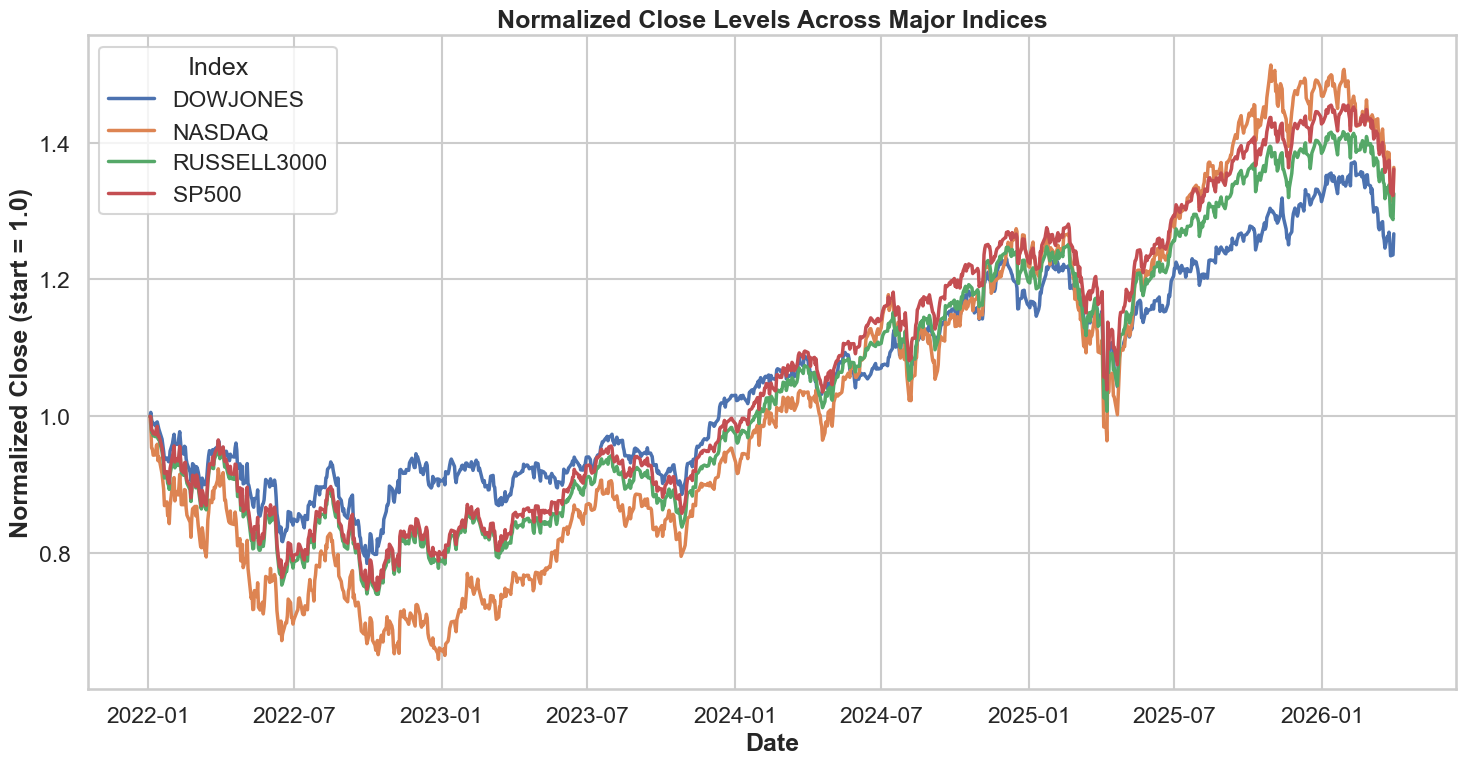

[TIMER] visual_normalized_close_levels: 0.25s


In [7]:
with timed_step('visual_normalized_close_levels'):
    normalized = raw_panel[['Date', 'index_key', 'Close']].copy()
    normalized['normalized_close'] = normalized.groupby('index_key')['Close'].transform(lambda s: s / float(s.iloc[0]))

    fig, ax = plt.subplots(figsize=(15, 8))
    sns.lineplot(data=normalized, x='Date', y='normalized_close', hue='index_key', linewidth=2.5, ax=ax)
    ax.set_title('Normalized Close Levels Across Major Indices')
    ax.set_ylabel('Normalized Close (start = 1.0)')
    ax.set_xlabel('Date')
    ax.legend(title='Index', frameon=True)
    fig.tight_layout()
    fig.savefig(FIG_DIR / '01_normalized_close_levels.png', dpi=200, bbox_inches='tight')
    plt.show()


/var/folders/5c/4q76bz797qb1jb4zx4q7j55c0000gn/T/ipykernel_52908/277497185.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=returns_plot, x='index_key', y='daily_return_pct', ax=axes[0], palette='Set2')


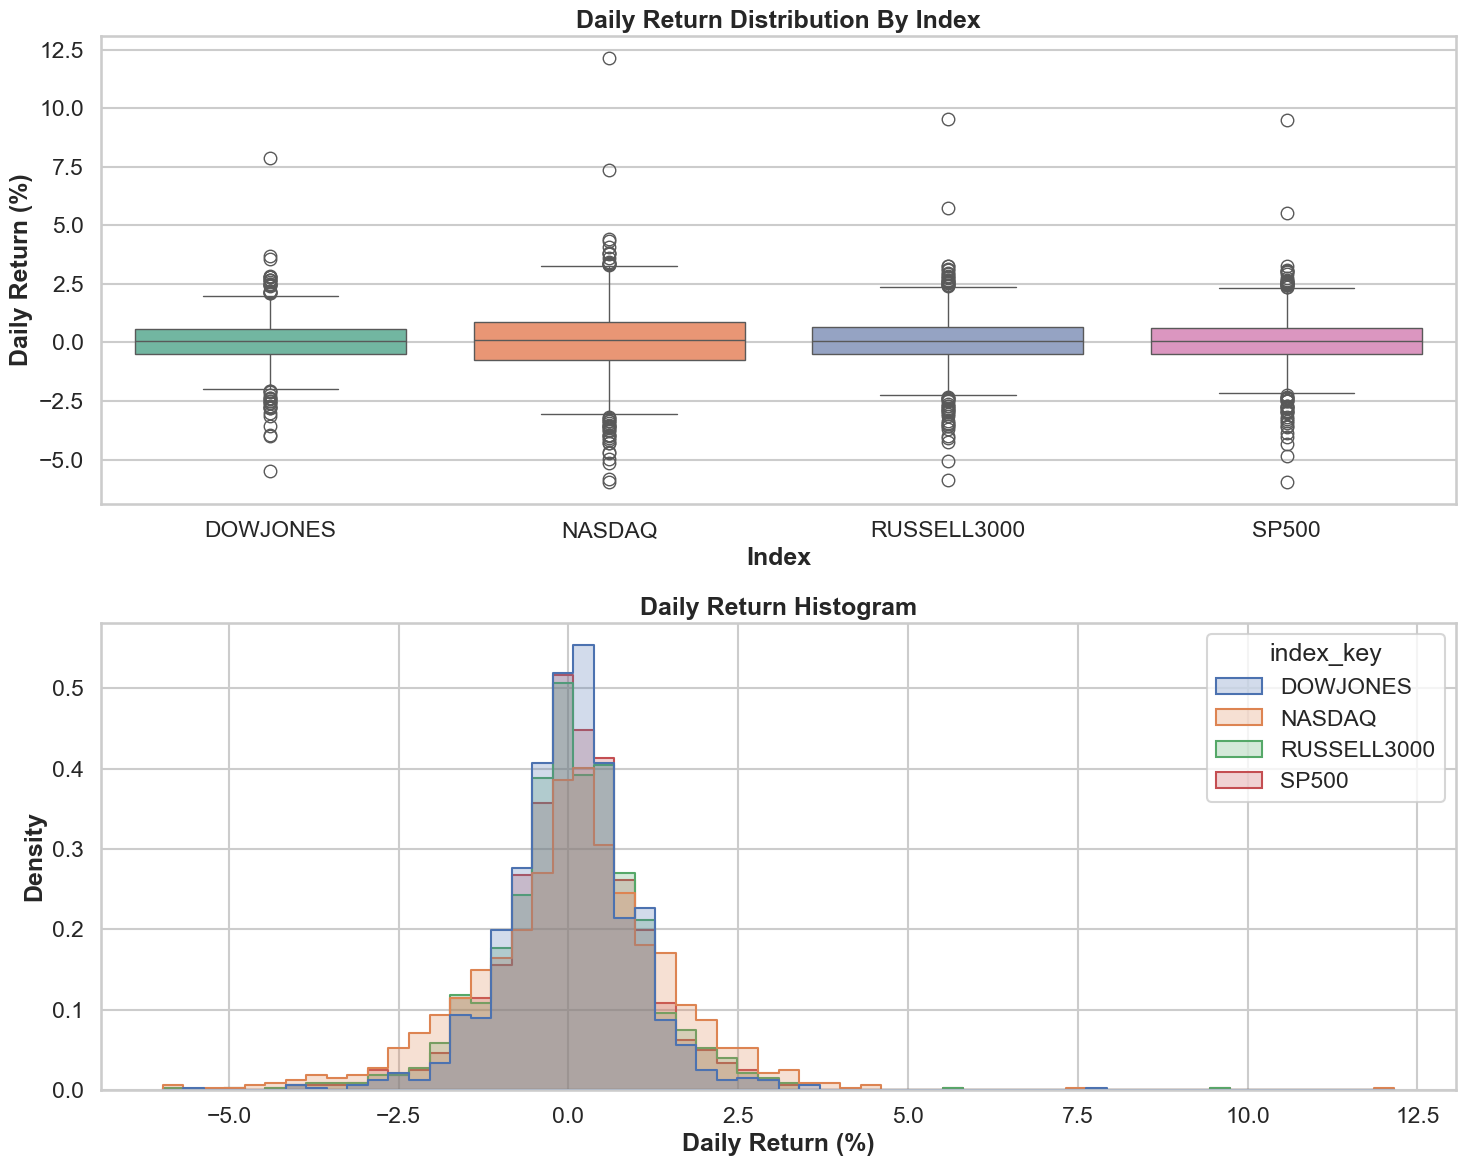

[TIMER] visual_daily_return_distribution: 0.29s


In [8]:
with timed_step('visual_daily_return_distribution'):
    returns_plot = return_panel.copy()
    returns_plot['daily_return_pct'] = returns_plot['daily_return'] * 100.0

    fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=False)
    sns.boxplot(data=returns_plot, x='index_key', y='daily_return_pct', ax=axes[0], palette='Set2')
    axes[0].set_title('Daily Return Distribution By Index')
    axes[0].set_xlabel('Index')
    axes[0].set_ylabel('Daily Return (%)')

    sns.histplot(
        data=returns_plot,
        x='daily_return_pct',
        hue='index_key',
        bins=60,
        element='step',
        stat='density',
        common_norm=False,
        ax=axes[1],
    )
    axes[1].set_title('Daily Return Histogram')
    axes[1].set_xlabel('Daily Return (%)')
    axes[1].set_ylabel('Density')
    fig.tight_layout()
    fig.savefig(FIG_DIR / '02_daily_return_distribution.png', dpi=200, bbox_inches='tight')
    plt.show()


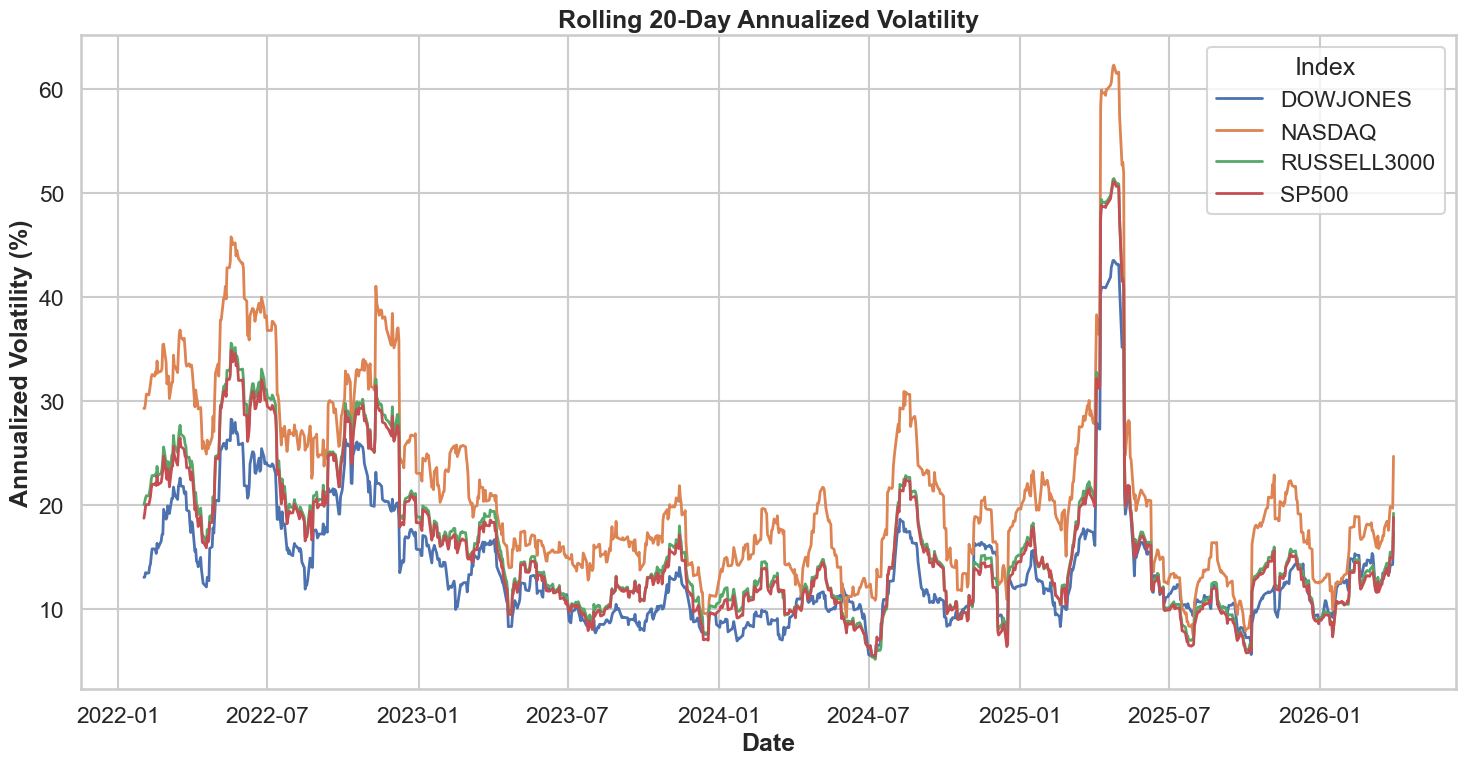

[TIMER] visual_rolling_volatility: 0.23s


In [9]:
with timed_step('visual_rolling_volatility'):
    volatility_plot = return_panel.copy()
    volatility_plot['rolling_20d_vol_pct'] = (
        volatility_plot.groupby('index_key')['daily_return']
        .transform(lambda s: s.rolling(20).std() * np.sqrt(TRADING_DAYS_PER_YEAR) * 100.0)
    )

    fig, ax = plt.subplots(figsize=(15, 8))
    sns.lineplot(data=volatility_plot, x='Date', y='rolling_20d_vol_pct', hue='index_key', linewidth=2.0, ax=ax)
    ax.set_title('Rolling 20-Day Annualized Volatility')
    ax.set_xlabel('Date')
    ax.set_ylabel('Annualized Volatility (%)')
    ax.legend(title='Index', frameon=True)
    fig.tight_layout()
    fig.savefig(FIG_DIR / '03_rolling_20d_annualized_volatility.png', dpi=200, bbox_inches='tight')
    plt.show()


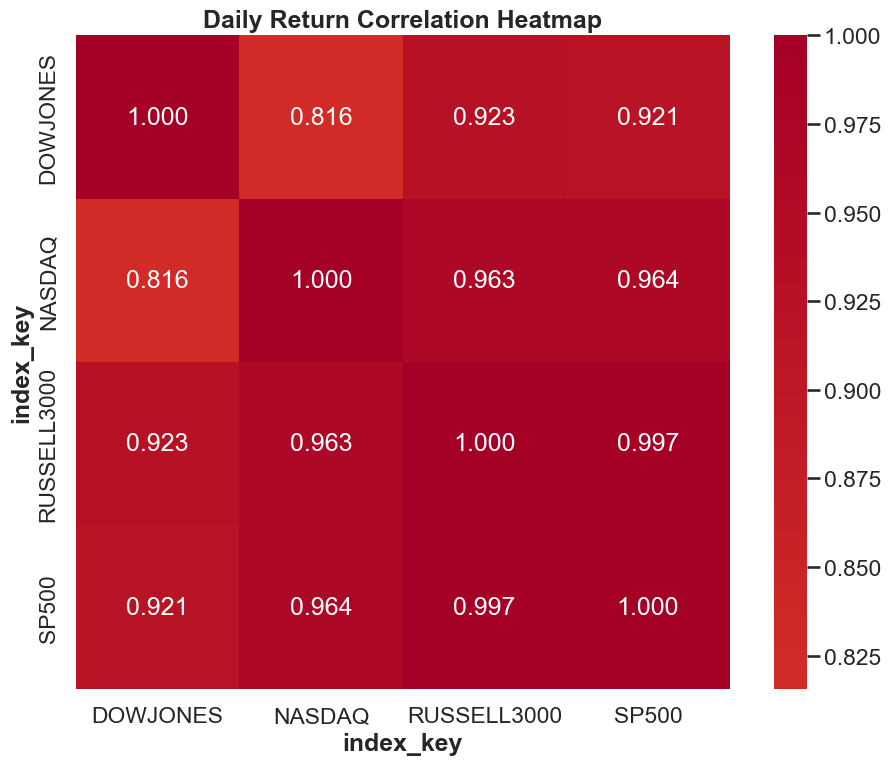

[TIMER] visual_return_correlation_heatmap: 0.12s


In [10]:
with timed_step('visual_return_correlation_heatmap'):
    return_matrix = return_panel.pivot(index='Date', columns='index_key', values='daily_return').sort_index()
    correlation_matrix = return_matrix.corr()
    correlation_matrix.to_csv(TABLE_DIR / 'daily_return_correlation_matrix.csv')

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0.0, square=True, ax=ax)
    ax.set_title('Daily Return Correlation Heatmap')
    fig.tight_layout()
    fig.savefig(FIG_DIR / '04_daily_return_correlation_heatmap.png', dpi=200, bbox_inches='tight')
    plt.show()


In [11]:
timing_summary = pd.DataFrame(TIMING_ROWS).sort_values('elapsed_seconds', ascending=False).reset_index(drop=True)
timing_summary.to_csv(TABLE_DIR / 'timing_summary.csv', index=False)


bundle = {
    'config': {
        'requested_start_date': REQUESTED_START_DATE,
        'requested_end_date': REQUESTED_END_DATE,
        'hp_tuning_start_date': HP_TUNING_START_DATE,
        'hp_tuning_end_date': HP_TUNING_END_DATE,
        'evaluation_start_date': EVALUATION_START_DATE,
        'indices': INDEX_META,
        'modeling_feature_cols': MODELING_FEATURE_COLS,
    },
    'raw_frames': raw_frames,
    'raw_panel': raw_panel,
    'return_panel': return_panel,
    'feature_panel': feature_panel,
    'quality_table': quality_table,
    'split_preview': split_preview,
    'close_stats': close_stats,
    'return_stats': return_stats,
    'technical_indicator_catalog': TECHNICAL_INDICATOR_CATALOG,
    'feature_coverage': feature_coverage,
    'timing_summary': timing_summary,
}
joblib.dump(bundle, MASTER_BUNDLE_PATH)

print('Timing summary')
display(timing_summary)
print('EDA bundle prepared')


Timing summary


,step,elapsed_seconds
0,download_raw_data,1.110638
1,visual_daily_return_distribution,0.285804
2,visual_normalized_close_levels,0.247007
3,visual_rolling_volatility,0.231261
4,visual_return_correlation_heatmap,0.122872
5,technical_indicator_panel,0.018682
6,descriptive_statistics,0.004898
7,data_quality_and_split_preview,0.003603


EDA bundle prepared
